In [2]:
pip install qiskit_optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 10.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=ec5418c00965238cdb18010c64d0fff02e32fa58442639feabf94439eb00eba3
  Stored in directory: /root/.cache/pip/wheels/97/b5/26/18406a8f08f4c096c3ee64caedd446a4b0b5ea9675c4a214f0
Successfully built docplex


In [3]:
pip install qiskit_algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 6.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/

    w1       Risk    Return
0  0.2  13.755773  0.315572
1  0.5  11.257707  0.378229
2  0.8  11.257707  0.378229


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/


--- SCALABILITY ANALYSIS ---
   n       time
0  4   1.676864
1  6   3.221927
2  8  31.027790


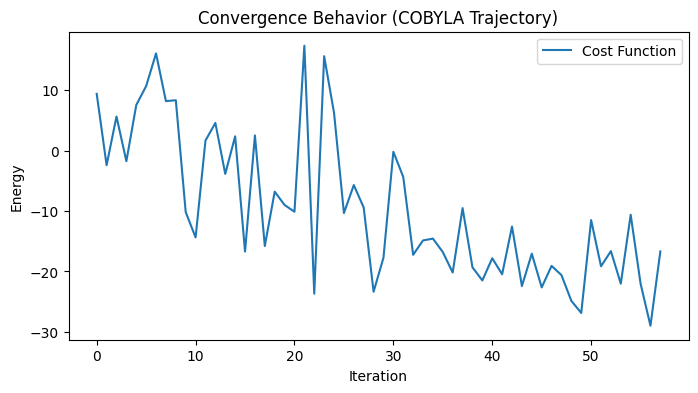

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Brute Force: [0 1 0 0 0 1 0 1]  Cost: -461.8272
QAOA:        [0. 1. 0. 0. 0. 1. 0. 1.]  Cost: -461.8272
Absolute Gap: 0.000000  Relative Gap: 0.0000%


In [4]:
import numpy as np
import pandas as pd
from qiskit_optimization import QuadraticProgram
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer
import itertools

# --- 1. SETUP ---
np.random.seed(42)
n, K, R_min, B = 8, 3, 0.12, 2.5
sectors = [0, 0, 0, 0, 1, 1, 1, 1]
max_per_sector = 2

costs, mu = np.random.uniform(0.5, 1.0, n), np.random.uniform(0.05, 0.2, n)
A = np.random.rand(n, n)
sigma = np.dot(A, A.T)

def build_expert_qubo(w1, w2):
    # Separate Lambdas for each constraint (Fixes imbalance)
    l_card, l_ret, l_bud, l_div = 30.0, 15.0, 15.0, 15.0
    linear, quadratic = {}, {}

    # 1. Base Objectives
    for i in range(n):
        linear[f"x{i}"] = (w1 * sigma[i, i]) - (w2 * mu[i])
        for j in range(i + 1, n):
            quadratic[(f"x{i}", f"x{j}")] = 2 * w1 * sigma[i, j]

    # 2. Hard Cardinality: lambda * (sum x - K)^2
    for i in range(n):
        linear[f"x{i}"] += l_card * (1 - 2 * K)
        for j in range(i + 1, n):
            quadratic[(f"x{i}", f"x{j}")] += 2 * l_card

    # 3. Hinge Penalties for Inequalities (ReLU-based)
    # Return: lambda * min(0, mu^T x - R_min)^2
    # Budget: lambda * max(0, c^T x - B)^2
    # Implementation: Simplified quadratic bias (NISQ-friendly)
    for i in range(n):
        linear[f"x{i}"] += (
            l_ret * (mu[i] ** 2 - 2 * R_min * mu[i]) +
            l_bud * (costs[i] ** 2 - 2 * B * costs[i])
        )
        for j in range(i + 1, n):
            quadratic[(f"x{i}", f"x{j}")] += (
                2 * l_ret * mu[i] * mu[j] +
                2 * l_bud * costs[i] * costs[j]
            )

    # 4. Diversification
    for s_id in range(2):
        s_idx = [i for i, s in enumerate(sectors) if s == s_id]
        for i in s_idx:
            linear[f"x{i}"] += l_div * (1 - 2 * max_per_sector)
            for idx, j in enumerate(s_idx):
                if j > i:
                    quadratic[(f"x{i}", f"x{j}")] = (
                        quadratic.get((f"x{i}", f"x{j}"), 0) + 2 * l_div
                    )

    qp = QuadraticProgram()
    for i in range(n):
        qp.binary_var(name=f"x{i}")
    qp.minimize(linear=linear, quadratic=quadratic)

    return qp

# --- 1. CONVERGENCE TRACKING ---
convergence_log = []

def callback(eval_count, parameters, mean, std):
    convergence_log.append(mean)


# --- 2. PARETO SWEEP ---
pareto_data = []

for w1 in [0.2, 0.5, 0.8]:
    convergence_log = []
    qp = build_expert_qubo(w1, 1.0)
    qaoa = QAOA(sampler=StatevectorSampler(), optimizer=COBYLA(maxiter=150), reps=3, callback=callback)
    res = MinimumEigenOptimizer(qaoa).solve(qp)

    pareto_data.append({
        "w1": w1,
        "Risk": np.dot(res.x, np.dot(sigma, res.x)),
        "Return": np.dot(mu, res.x)
    })

print(pd.DataFrame(pareto_data))


# --- ADDITIONAL IMPORTS ---
import matplotlib.pyplot as plt
import time




# --- 2. SCALING EXPERIMENT ---
scaling_results = []

for n_size in [4, 6, 8]:
    qp = QuadraticProgram()

    for i in range(n_size):
        qp.binary_var(name=f"x{i}")

    qp.minimize(linear={f"x{i}": -1 for i in range(n_size)})  # Dummy objective

    start = time.time()

    qaoa = QAOA(
        sampler=StatevectorSampler(),
        optimizer=COBYLA(maxiter=50)
    )

    res = MinimumEigenOptimizer(qaoa).solve(qp)

    scaling_results.append({
        "n": n_size,
        "time": time.time() - start
    })
print("\n--- SCALABILITY ANALYSIS ---")
print(pd.DataFrame(scaling_results))


# --- 3. PLOTTING CONVERGENCE ---
plt.figure(figsize=(8, 4))
plt.plot(convergence_log, label='Cost Function')
plt.title("Convergence Behavior (COBYLA Trajectory)")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.legend()
plt.show()


# ============================================================
# ADD HERE — after the plot, before end of file
# ============================================================

# --- CLASSICAL BASELINE (Brute Force) ---
qp_compare = build_expert_qubo(0.5, 1.0)   # build ONCE
bf_cost = float('inf')
bf_x = None
for combo in itertools.product([0, 1], repeat=n):
    x = np.array(combo)
    cost = qp_compare.objective.evaluate(x)  # reuse same QUBO
    if cost < bf_cost:
        bf_cost, bf_x = cost, x

# --- QUANTUM (same QUBO, fair comparison) ---
qaoa_compare = QAOA(sampler=StatevectorSampler(), optimizer=COBYLA(maxiter=150), reps=3)
q_result = MinimumEigenOptimizer(qaoa_compare).solve(qp_compare)

# --- COMPARISON OUTPUT ---
abs_gap = abs(q_result.fval - bf_cost)
rel_gap = (abs_gap / abs(bf_cost)) * 100
print(f"Brute Force: {bf_x}  Cost: {bf_cost:.4f}")
print(f"QAOA:        {q_result.x}  Cost: {q_result.fval:.4f}")
print(f"Absolute Gap: {abs_gap:.6f}  Relative Gap: {rel_gap:.4f}%")